# STEP 4 — Program Impact Classification & Effectiveness Prediction

Tahap ini bertujuan untuk membangun model Machine Learning untuk:
1. Mengklasifikasikan kategori dampak program pemerintah.
2. Memprediksi skor efektivitas program.
3. Membandingkan performa beberapa algoritma.
4. Menyimpan model terbaik untuk digunakan pada Executive Dashboard.

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 2. LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv(
    "../data/processed/program_impact_cleaned.csv",
    parse_dates=["start_date"]
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 26)


,program_id,program_name,department,district,start_date,budget_allocated,beneficiaries,completion_rate,budget_utilization,satisfaction_score,...,impact_category,implementation_status,risk_level,strategic_recommendation,budget_efficiency_score,beneficiary_scale,satisfaction_category,budget_tier,program_age_days,program_maturity
0,PRG-00001,Digital UMKM Empowerment,Dinas Koperasi,Batu,2024-10-08,1551802512,16295,68.66,91.19,4.25,...,Moderate Impact,In Progress,Medium,Optimize delivery and improve stakeholder enga...,85.765983,Medium Scale,High,Tier 1,581,Established
1,PRG-00002,Public WiFi Expansion,DISKOMINFO,Bumiaji,2024-04-14,9463334018,2933,83.97,83.37,3.84,...,Moderate Impact,Completed,Medium,Optimize delivery and improve stakeholder enga...,94.170565,Small Scale,Moderate,Tier 4,758,Mature
2,PRG-00003,Education Assistance,Dinas Pendidikan,Batu,2024-01-31,902418010,19442,76.86,80.58,3.71,...,Low Impact,Completed,High,Conduct a strategic review and redesign the pr...,86.200050,Medium Scale,Moderate,Tier 1,832,Mature
3,PRG-00004,Tourism Promotion Campaign,Dinas Pariwisata,Bumiaji,2025-09-08,9203905715,1767,99.84,82.56,4.16,...,High Impact,Expanded,Low,Scale up program implementation.,108.696705,Small Scale,High,Tier 4,246,Growing
4,PRG-00005,Tourism Promotion Campaign,Dinas Pariwisata,Bumiaji,2025-10-27,2301823908,22277,74.80,97.47,4.26,...,Moderate Impact,In Progress,Medium,Optimize delivery and improve stakeholder enga...,85.421155,Large Scale,High,Tier 1,197,Growing


In [2]:
# =========================================================
# 3. FEATURE SELECTION
# =========================================================

# Features used for modeling
feature_columns = [
    "program_name",
    "department",
    "district",
    "budget_allocated",
    "beneficiaries",
    "completion_rate",
    "budget_utilization",
    "satisfaction_score",
    "social_engagement",
    "sentiment_score",
    "reach_rate",
    "cost_per_beneficiary",
    "roi_score",
    "budget_efficiency_score",
    "program_age_days",
    "beneficiary_scale",
    "satisfaction_category",
    "budget_tier",
    "program_maturity"
]

X = df[feature_columns]

# Targets
y_class = df["impact_category"]
y_reg = df["effectiveness_score"]

# =========================================================
# 4. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (8000, 19)
X_test : (2000, 19)


In [3]:
# =========================================================
# 5. PREPROCESSING PIPELINE
# =========================================================

categorical_features = [
    "program_name",
    "department",
    "district",
    "beneficiary_scale",
    "satisfaction_category",
    "budget_tier",
    "program_maturity"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [4]:
# =========================================================
# 6. IMPACT CATEGORY CLASSIFICATION
# =========================================================

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
}

classification_results = {}
best_classifier = None
best_classifier_name = None
best_classifier_f1 = 0
best_classifier_pred = None

for name, model in classification_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_class)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test_class, y_pred)
    f1 = f1_score(
        y_test_class,
        y_pred,
        average="macro"
    )

    classification_results[name] = {
        "Accuracy": acc,
        "F1 Score": f1
    }

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print()
    print(classification_report(y_test_class, y_pred))

    if f1 > best_classifier_f1:
        best_classifier_f1 = f1
        best_classifier = pipeline
        best_classifier_name = name
        best_classifier_pred = y_pred

classification_results_df = (
    pd.DataFrame(classification_results)
    .T
    .sort_values("F1 Score", ascending=False)
)

print("\n🏆 Best Classification Model:", best_classifier_name)
print(f"Macro F1 Score: {best_classifier_f1:.4f}")

classification_results_df

Logistic Regression
Accuracy : 0.7460
F1 Score : 0.2848

                 precision    recall  f1-score   support

    High Impact       0.00      0.00      0.00       456
     Low Impact       0.00      0.00      0.00        52
Moderate Impact       0.75      1.00      0.85      1492

       accuracy                           0.75      2000
      macro avg       0.25      0.33      0.28      2000
   weighted avg       0.56      0.75      0.64      2000



c:\Users\wildan nabila\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wildan nabila\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wildan nabila\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

Random Forest
Accuracy : 0.9990
F1 Score : 0.9932

                 precision    recall  f1-score   support

    High Impact       1.00      1.00      1.00       456
     Low Impact       1.00      0.96      0.98        52
Moderate Impact       1.00      1.00      1.00      1492

       accuracy                           1.00      2000
      macro avg       1.00      0.99      0.99      2000
   weighted avg       1.00      1.00      1.00      2000


🏆 Best Classification Model: Random Forest
Macro F1 Score: 0.9932


,Accuracy,F1 Score
Random Forest,0.999,0.993241
Logistic Regression,0.746,0.284842


In [6]:
# =========================================================
# 7. EFFECTIVENESS SCORE PREDICTION
# =========================================================

regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
}

regression_results = {}
best_regressor = None
best_regressor_name = None
best_regressor_r2 = -999
best_regression_pred = None

for name, model in regression_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_reg)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test_reg,
        y_pred
    )
    r2 = r2_score(
        y_test_reg,
        y_pred
    )

    regression_results[name] = {
        "MAE": mae,
        "R2 Score": r2
    }

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"MAE      : {mae:.4f}")
    print(f"R² Score : {r2:.4f}")

    if r2 > best_regressor_r2:
        best_regressor_r2 = r2
        best_regressor = pipeline
        best_regressor_name = name
        best_regression_pred = y_pred

regression_results_df = (
    pd.DataFrame(regression_results)
    .T
    .sort_values("R2 Score", ascending=False)
)

print("\n🏆 Best Regression Model:", best_regressor_name)
print(f"R² Score: {best_regressor_r2:.4f}")

regression_results_df

Linear Regression
MAE      : 4.2348
R² Score : -0.0064
Random Forest Regressor
MAE      : 4.2647
R² Score : -0.0221

🏆 Best Regression Model: Linear Regression
R² Score: -0.0064


,MAE,R2 Score
Linear Regression,4.234832,-0.006354
Random Forest Regressor,4.264749,-0.022078


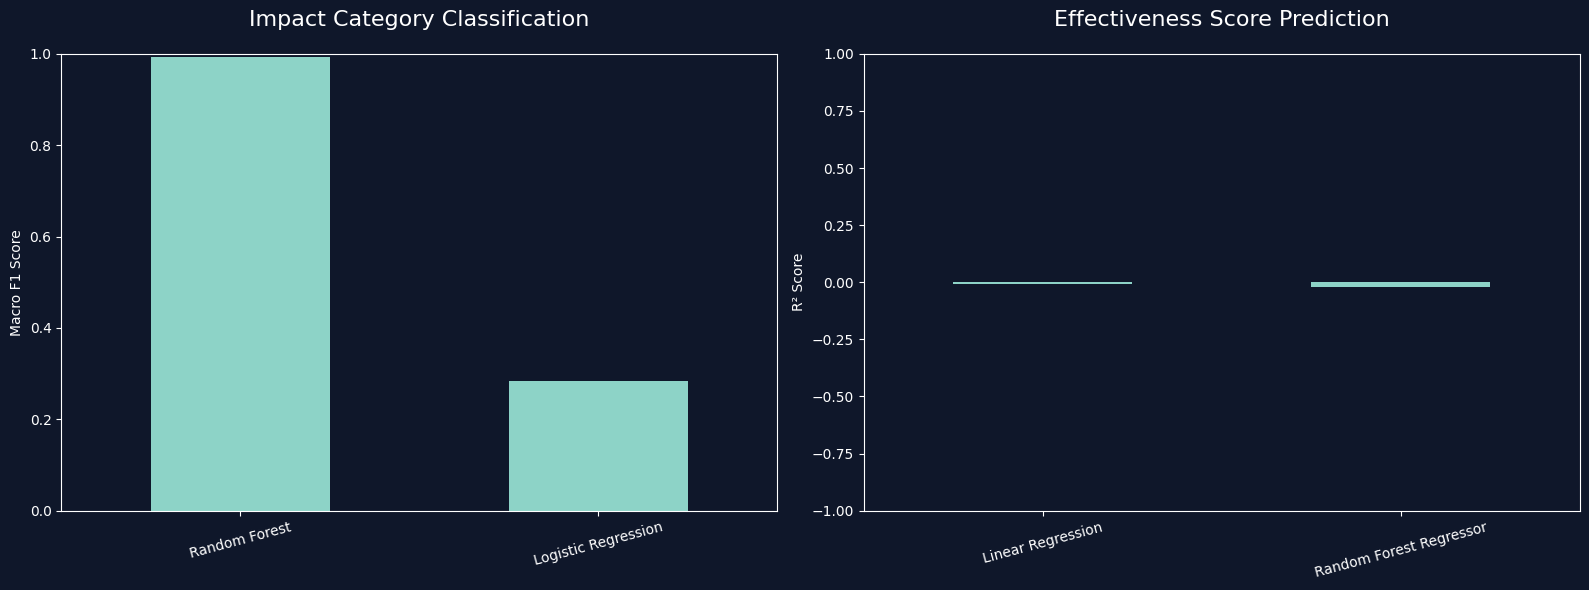

In [9]:
# =========================================================
# 8. MODEL PERFORMANCE VISUALIZATION
# =========================================================

plt.style.use("dark_background")
plt.rcParams["figure.facecolor"] = "#0F172A"
plt.rcParams["axes.facecolor"] = "#0F172A"
plt.rcParams["savefig.facecolor"] = "#0F172A"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Classification Performance (Macro F1 Score)
# ---------------------------------------------------------
classification_results_df["F1 Score"].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title(
    "Impact Category Classification",
    fontsize=16,
    pad=20
)
axes[0].set_ylabel("Macro F1 Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

# ---------------------------------------------------------
# Regression Performance (R² Score)
# ---------------------------------------------------------
regression_results_df["R2 Score"].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title(
    "Effectiveness Score Prediction",
    fontsize=16,
    pad=20
)
axes[1].set_ylabel("R² Score")
min_r2 = regression_results_df["R2 Score"].min()
max_r2 = regression_results_df["R2 Score"].max()

axes[1].set_ylim(
    min(min_r2 - 0.1, -1),
    max(max_r2 + 0.1, 1)
)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Save screenshot as:
# assets/model-performance-comparison.png

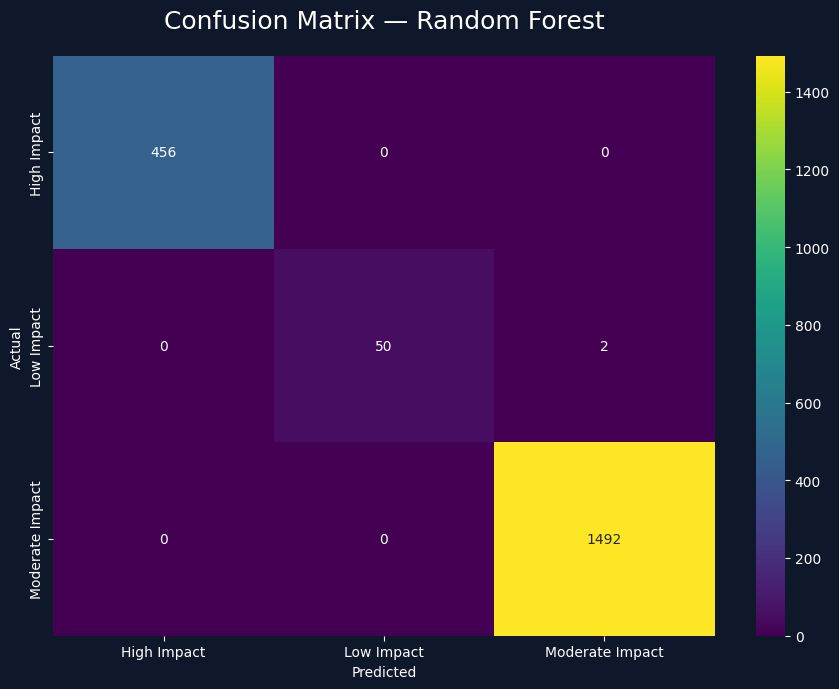

In [10]:
# =========================================================
# 9. CONFUSION MATRIX
# =========================================================

labels = best_classifier.named_steps["model"].classes_

cm = confusion_matrix(
    y_test_class,
    best_classifier_pred,
    labels=labels
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    f"Confusion Matrix — {best_classifier_name}",
    fontsize=18,
    pad=20
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save screenshot as:
# assets/impact-confusion-matrix.png

In [11]:
# =========================================================
# 11. EXECUTIVE MODEL SUMMARY
# =========================================================

print("=" * 70)
print("EXECUTIVE MODEL SUMMARY")
print("=" * 70)
print(f"Best Classification Model : {best_classifier_name}")
print(f"Classification F1 Score   : {best_classifier_f1:.4f}")
print()
print(f"Best Regression Model     : {best_regressor_name}")
print(f"Regression R² Score       : {best_regressor_r2:.4f}")
print()
print("Strategic Insight:")
print(
    "The AI models can automatically evaluate government programs, "
    "classify their impact level, and predict effectiveness scores "
    "to support evidence-based budget allocation and policy decisions."
)
print("=" * 70)

EXECUTIVE MODEL SUMMARY
Best Classification Model : Random Forest
Classification F1 Score   : 0.9932

Best Regression Model     : Linear Regression
Regression R² Score       : -0.0064

Strategic Insight:
The AI models can automatically evaluate government programs, classify their impact level, and predict effectiveness scores to support evidence-based budget allocation and policy decisions.
